# 01 数据概览与清洗

**目标**：加载数据，了解数据规模、字段含义、质量状况，完成基础清洗。

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data, clean_data

sns.set_style('whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 加载数据（使用模拟数据演示；有真实数据时替换 data_path）
df, item_meta = load_data(use_simulated=True, n_users=5000)
df = clean_data(df)

生成模拟数据：5000 个用户...
共 138,206 条行为记录，6 个品类


In [3]:
# 数据基本信息
print(f'数据时间范围: {df["timestamp"].min()} ~ {df["timestamp"].max()}')
print(f'用户数: {df["user_id"].nunique():,}')
print(f'商品数: {df["item_id"].nunique():,}')
print(f'行为类型: {df["behavior_type"].unique()}')

数据时间范围: 2026-03-01 00:05:00 ~ 2026-04-30 00:00:10
用户数: 5,000
商品数: 200
行为类型: ['pv' 'fav' 'cart' 'buy']


In [4]:
# 各行为类型分布
behavior_counts = df['behavior_type'].value_counts()
behavior_pct = df['behavior_type'].value_counts(normalize=True) * 100
behavior_summary = pd.DataFrame({'数量': behavior_counts, '占比(%)': behavior_pct.round(2)})
behavior_summary.T

behavior_type,pv,fav,cart,buy
数量,112242.00,13500.00,9039.00,3425.00
占比(%),81.21,9.77,6.54,2.48


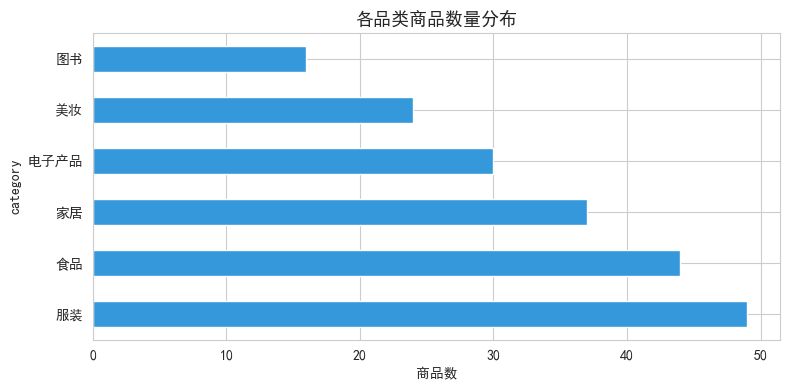

In [5]:
# 各品类商品分布
if item_meta is not None:
    cat_counts = item_meta['category'].value_counts()
    plt.figure(figsize=(8, 4))
    cat_counts.plot(kind='barh', color='#3498db')
    plt.title('各品类商品数量分布', fontsize=13, fontweight='bold')
    plt.xlabel('商品数')
    plt.tight_layout()
    plt.show()

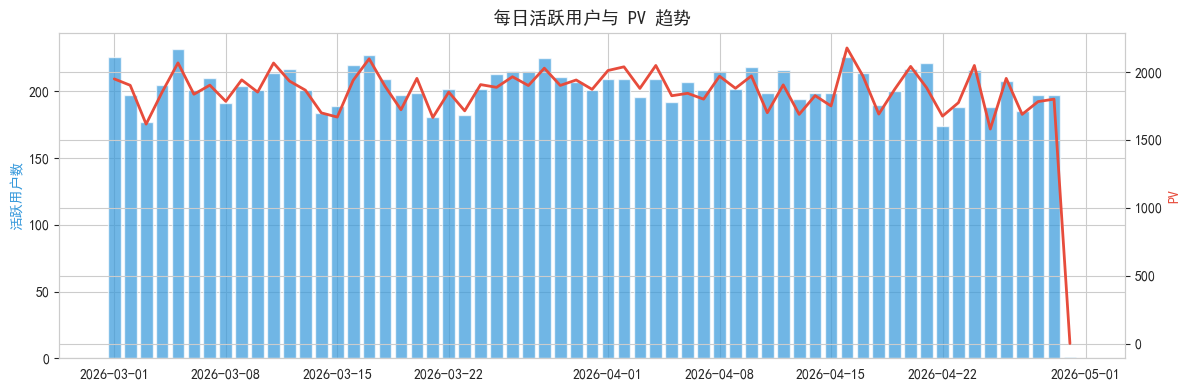

In [6]:
# 每日活跃用户趋势
df['date'] = df['timestamp'].dt.date
daily_users = df.groupby('date')['user_id'].nunique()
daily_pv = df[df['behavior_type'] == 'pv'].groupby('date').size()

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.bar(daily_users.index, daily_users.values, color='#3498db', alpha=0.7, label='日活用户')
ax1.set_ylabel('活跃用户数', color='#3498db')
ax2 = ax1.twinx()
ax2.plot(daily_users.index, daily_pv.values, color='#e74c3c', linewidth=2, label='日 PV')
ax2.set_ylabel('PV', color='#e74c3c')
plt.title('每日活跃用户与 PV 趋势', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

---
### 本阶段结论
- 数据规模：约 XX 万条行为记录，覆盖 YY 用户和 ZZ 商品
- 行为分布：pv 占主导（~75%），购买转化约 3%
- 数据清洗：去除了 X 条重复、Y 条缺失
- 下一步：进入漏斗分析